In [1]:
!pip install sentence-transformers -q

# Project 3 — Semantic Search Engine

Built a semantic search engine using sentence embeddings that finds 
similar documents by meaning rather than keyword overlap.

## How It Works
1. Load SentenceTransformer model (all-MiniLM-L6-v2)
2. Encode all documents into 384-dimensional vectors
3. Encode query into same vector space
4. Compute cosine similarity between query and all documents
5. Return top-k most similar documents

## Key Results
- Correctly finds "microservices" for query "splitting applications into parts"
- Correctly finds "Redis" for query "storing data temporarily"  
- Outperforms keyword search on all semantic queries

## Why This Matters
This is the retrieval component of RAG (Retrieval Augmented Generation).
In Week 4 we wire this to an LLM to build a full Q&A system over documents.

## Tech Stack
- Model: all-MiniLM-L6-v2 (SentenceTransformers)
- Similarity: Cosine similarity
- Visualization: PCA dimensionality reduction

In [2]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import torch

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded")
print("Max sequence length:", model.max_seq_length)
print("Embedding dimension:", model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded
Max sequence length: 256
Embedding dimension: 384


In [4]:
documents = [
    # Distributed systems (your domain)
    "Kubernetes orchestrates containerized applications across clusters",
    "Docker containers package applications with their dependencies",
    "Apache Kafka is a distributed streaming platform for real-time data",
    "Redis is an in-memory data store used for caching and messaging",
    "Load balancers distribute network traffic across multiple servers",
    "Microservices architecture splits applications into small independent services",
    "CAP theorem states distributed systems can only guarantee two of three properties",
    "Service mesh manages communication between microservices",
    
    # Machine learning
    "Neural networks learn patterns from labeled training data",
    "Gradient descent minimizes the loss function during training",
    "Transformers use attention mechanisms to process sequential data",
    "Fine-tuning adapts pretrained models to specific downstream tasks",
    "Embeddings represent words or sentences as dense numerical vectors",
    "BERT is a bidirectional transformer pretrained on masked language modeling",
    
    # General tech
    "Python is a high level programming language popular in data science",
    "REST APIs use HTTP methods to communicate between services",
    "SQL databases store structured data in tables with relationships",
    "Git is a version control system for tracking code changes",
]

print(f"Document collection: {len(documents)} documents")

Document collection: 18 documents


In [5]:
# Encode all documents into vectors
doc_embeddings = model.encode(documents, convert_to_tensor=True)

print("Embedding shape:", doc_embeddings.shape)
print(f"Each document → vector of {doc_embeddings.shape[1]} numbers")
print(f"All {doc_embeddings.shape[0]} documents encoded")

Embedding shape: torch.Size([18, 384])
Each document → vector of 384 numbers
All 18 documents encoded


In [6]:
def semantic_search(query, top_k=3):
    # Encode the query into same vector space
    query_embedding = model.encode(query, convert_to_tensor=True)
    
    # Compute cosine similarity between query and all documents
    similarities = util.cos_sim(query_embedding, doc_embeddings)[0]
    
    # Get top k most similar documents
    top_results = torch.topk(similarities, k=top_k)
    
    print(f"\n🔍 Query: '{query}'")
    print("-" * 60)
    for score, idx in zip(top_results.values, top_results.indices):
        print(f"Score: {score:.4f} | {documents[idx]}")
    
    return top_results

# Test it
semantic_search("how do containers work")


🔍 Query: 'how do containers work'
------------------------------------------------------------
Score: 0.4327 | Kubernetes orchestrates containerized applications across clusters
Score: 0.4015 | Docker containers package applications with their dependencies
Score: 0.2229 | Microservices architecture splits applications into small independent services


torch.return_types.topk(
values=tensor([0.4327, 0.4015, 0.2229]),
indices=tensor([0, 1, 5]))

In [7]:
queries = [
    "how do containers work",
    "machine learning optimization",
    "splitting applications into parts",
    "storing data temporarily",
    "how transformers process text",
    "managing traffic across servers",
]

for query in queries:
    semantic_search(query, top_k=3)
    print()


🔍 Query: 'how do containers work'
------------------------------------------------------------
Score: 0.4327 | Kubernetes orchestrates containerized applications across clusters
Score: 0.4015 | Docker containers package applications with their dependencies
Score: 0.2229 | Microservices architecture splits applications into small independent services


🔍 Query: 'machine learning optimization'
------------------------------------------------------------
Score: 0.4653 | Gradient descent minimizes the loss function during training
Score: 0.3720 | Neural networks learn patterns from labeled training data
Score: 0.3619 | Fine-tuning adapts pretrained models to specific downstream tasks


🔍 Query: 'splitting applications into parts'
------------------------------------------------------------
Score: 0.4095 | Microservices architecture splits applications into small independent services
Score: 0.3611 | Docker containers package applications with their dependencies
Score: 0.3111 | Kubernetes o

In [8]:
def keyword_search(query, top_k=3):
    query_words = set(query.lower().split())
    scores = []
    
    for doc in documents:
        doc_words = set(doc.lower().split())
        # Simple overlap score
        overlap = len(query_words & doc_words)
        scores.append(overlap)
    
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    print(f"\n🔑 Keyword Search: '{query}'")
    print("-" * 60)
    for idx in top_indices:
        print(f"Score: {scores[idx]} | {documents[idx]}")

# Compare both approaches on same queries
comparison_queries = [
    "how do containers work",
    "splitting applications into parts",
    "storing data temporarily",
]

for query in comparison_queries:
    semantic_search(query, top_k=3)
    keyword_search(query, top_k=3)
    print("\n" + "="*60)


🔍 Query: 'how do containers work'
------------------------------------------------------------
Score: 0.4327 | Kubernetes orchestrates containerized applications across clusters
Score: 0.4015 | Docker containers package applications with their dependencies
Score: 0.2229 | Microservices architecture splits applications into small independent services

🔑 Keyword Search: 'how do containers work'
------------------------------------------------------------
Score: 1 | Docker containers package applications with their dependencies
Score: 0 | Git is a version control system for tracking code changes
Score: 0 | SQL databases store structured data in tables with relationships


🔍 Query: 'splitting applications into parts'
------------------------------------------------------------
Score: 0.4095 | Microservices architecture splits applications into small independent services
Score: 0.3611 | Docker containers package applications with their dependencies
Score: 0.3111 | Kubernetes orchestrates c

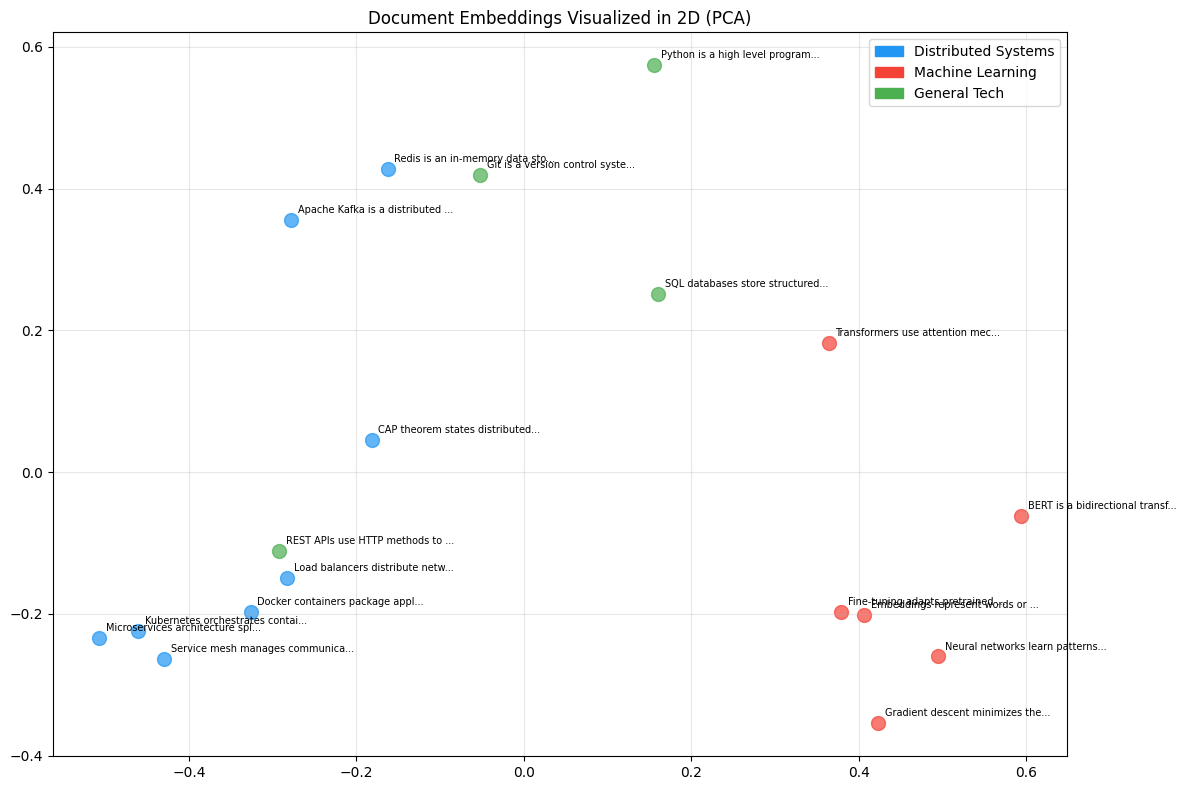

In [9]:
!pip install matplotlib scikit-learn -q

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reduce 384 dimensions to 2 for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(doc_embeddings.cpu().numpy())

# Color by category
colors = ['#2196F3'] * 8 + ['#F44336'] * 6 + ['#4CAF50'] * 4
labels = ['Distributed Systems'] * 8 + ['Machine Learning'] * 6 + ['General Tech'] * 4

plt.figure(figsize=(12, 8))
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, c=colors[i], s=100, alpha=0.7)
    plt.annotate(
        documents[i][:30] + "...",
        (x, y),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=7
    )

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Distributed Systems'),
    Patch(color='#F44336', label='Machine Learning'),
    Patch(color='#4CAF50', label='General Tech'),
]
plt.legend(handles=legend)
plt.title("Document Embeddings Visualized in 2D (PCA)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# This is EXACTLY what RAG does — retrieve then answer
def mini_rag(question):
    print(f"\n❓ Question: {question}")
    print("-" * 60)
    
    # Step 1 — Retrieve relevant context (semantic search)
    query_embedding = model.encode(question, convert_to_tensor=True)
    similarities = util.cos_sim(query_embedding, doc_embeddings)[0]
    top_results = torch.topk(similarities, k=2)
    
    context = []
    print("📚 Retrieved context:")
    for score, idx in zip(top_results.values, top_results.indices):
        if score > 0.25:  # minimum threshold
            context.append(documents[idx])
            print(f"  [{score:.3f}] {documents[idx]}")
    
    # Step 2 — In Week 4 you'll pass this context to an LLM
    # For now just show what would be passed
    print(f"\n📤 Context that would be sent to LLM:")
    for i, doc in enumerate(context):
        print(f"  {i+1}. {doc}")
    print(f"\n💡 LLM would answer '{question}' using above context")

mini_rag("how does kubernetes handle containers")
mini_rag("what is the CAP theorem")
mini_rag("how do neural networks learn")


❓ Question: how does kubernetes handle containers
------------------------------------------------------------
📚 Retrieved context:
  [0.798] Kubernetes orchestrates containerized applications across clusters
  [0.507] Docker containers package applications with their dependencies

📤 Context that would be sent to LLM:
  1. Kubernetes orchestrates containerized applications across clusters
  2. Docker containers package applications with their dependencies

💡 LLM would answer 'how does kubernetes handle containers' using above context

❓ Question: what is the CAP theorem
------------------------------------------------------------
📚 Retrieved context:
  [0.566] CAP theorem states distributed systems can only guarantee two of three properties

📤 Context that would be sent to LLM:
  1. CAP theorem states distributed systems can only guarantee two of three properties

💡 LLM would answer 'what is the CAP theorem' using above context

❓ Question: how do neural networks learn
---------------